## Book Recommendation

In [1]:
import pandas as pd
import numpy as np

## Task : EDA

##### User Dataset 

In [2]:
#Load dataset
users = pd.read_csv('Users.csv', encoding='latin-1')
#display dataset
users.head()

,User-ID,Location,Age
0,1,"nyc, new york, usa",NaN
1,2,"stockton, california, usa",18.0
2,3,"moscow, yukon territory, russia",NaN
3,4,"porto, v.n.gaia, portugal",17.0
4,5,"farnborough, hants, united kingdom",NaN


In [3]:
#Split a Location
users[['City', 'State', 'Country']] = users['Location'].str.split(',', n=2, expand=True)
#drop a Location
users.drop('Location',axis=1,inplace=True)

In [4]:
#Again Display data's
users.head()

,User-ID,Age,City,State,Country
0,1,NaN,nyc,new york,usa
1,2,18.0,stockton,california,usa
2,3,NaN,moscow,yukon territory,russia
3,4,17.0,porto,v.n.gaia,portugal
4,5,NaN,farnborough,hants,united kingdom


In [5]:
#information about user
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 278858 entries, 0 to 278857
Data columns (total 5 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   User-ID  278858 non-null  int64  
 1   Age      168096 non-null  float64
 2   City     278858 non-null  object 
 3   State    278857 non-null  object 
 4   Country  278856 non-null  object 
dtypes: float64(1), int64(1), object(3)
memory usage: 10.6+ MB


In [6]:
#check is value
users.isnull().sum()

User-ID         0
Age        110762
City            0
State           1
Country         2
dtype: int64

In [7]:
users['Age'] = users['Age'].fillna(users['Age'].median())  

In [8]:
# Remove unrealistic values
users = users[(users['Age'] >= 10) & (users['Age'] <= 80)]

In [9]:
bins = [10, 20, 30, 40, 50, 60, 70, 80]
labels = ['10-20', '21-30', '31-40', '41-50', '51-60', '61-70', '71-80']

users['Age_Group'] = pd.cut(users['Age'], bins=bins, labels=labels)

In [10]:
users.isnull().sum()

User-ID       0
Age           0
City          0
State         1
Country       2
Age_Group    84
dtype: int64

In [11]:
#Handling missing value
users['Age_Group'] = users['Age_Group'].astype(str)
users['Age_Group'] = users['Age_Group'].replace('nan', 'Unknown')

In [12]:
users['State'] = users['State'].fillna(users['State'].mode()[0])
users['Country'] = users['Country'].fillna(users['Country'].mode()[0])

In [13]:
users.head()

,User-ID,Age,City,State,Country,Age_Group
0,1,32.0,nyc,new york,usa,31-40
1,2,18.0,stockton,california,usa,10-20
2,3,32.0,moscow,yukon territory,russia,31-40
3,4,17.0,porto,v.n.gaia,portugal,10-20
4,5,32.0,farnborough,hants,united kingdom,31-40


In [14]:
users.isnull().sum()

User-ID      0
Age          0
City         0
State        0
Country      0
Age_Group    0
dtype: int64

In [15]:
#shape of users
users.shape[0]

277203

In [16]:
users['User-ID'].nunique() # unique users

277203

In [17]:
#Age Distribution
users['Age_Group'].value_counts().sort_index()

Age_Group
10-20       22866
21-30       52261
31-40      151015
41-50       25898
51-60       17596
61-70        6106
71-80        1377
Unknown        84
Name: count, dtype: int64

In [18]:
#Top Countries
users['Country'].value_counts().head(10)

Country
 usa               138512
 canada             21461
 united kingdom     18160
 germany            16909
 spain              12996
 australia          11602
 italy              11181
                     4539
 france              3415
 portugal            3272
Name: count, dtype: int64

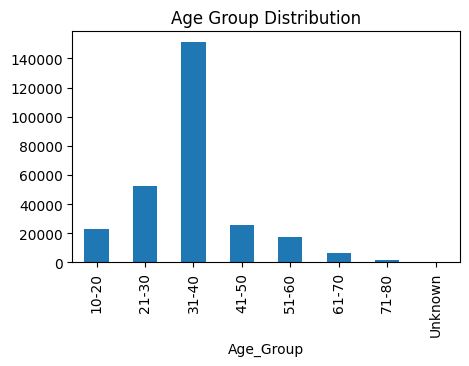

In [19]:
#Visualization
import matplotlib.pyplot as plt

# Age Group Plot
plt.figure(figsize=(5,3))
users['Age_Group'].value_counts().sort_index().plot(kind='bar')

plt.title("Age Group Distribution")
plt.show()

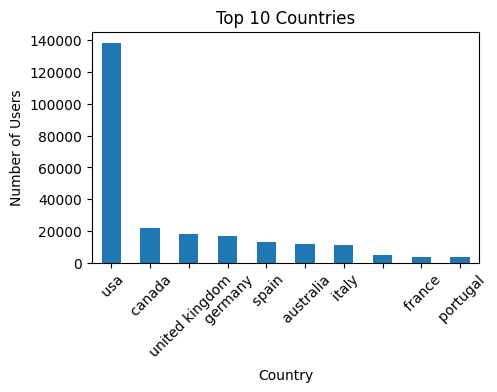

In [20]:
# Top Countries
plt.figure(figsize=(5,3))
users['Country'].value_counts().head(10).plot(kind='bar')
plt.title("Top 10 Countries")
plt.xlabel("Country")
plt.ylabel("Number of Users")
plt.xticks(rotation=45)
plt.show()

##### Books Dataset

In [21]:
#Load Books Dataset
books = pd.read_csv('Books.csv', encoding='latin-1', low_memory=False)
#display dataset
books.head()

,ISBN,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-S,Image-URL-M,Image-URL-L
0,0195153448,Classical Mythology,Mark P. O. Morford,2002,Oxford University Press,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...
1,0002005018,Clara Callan,Richard Bruce Wright,2001,HarperFlamingo Canada,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...
2,0060973129,Decision in Normandy,Carlo D'Este,1991,HarperPerennial,http://images.amazon.com/images/P/0060973129.0...,http://images.amazon.com/images/P/0060973129.0...,http://images.amazon.com/images/P/0060973129.0...
3,0374157065,Flu: The Story of the Great Influenza Pandemic...,Gina Bari Kolata,1999,Farrar Straus Giroux,http://images.amazon.com/images/P/0374157065.0...,http://images.amazon.com/images/P/0374157065.0...,http://images.amazon.com/images/P/0374157065.0...
4,0393045218,The Mummies of Urumchi,E. J. W. Barber,1999,W. W. Norton &amp; Company,http://images.amazon.com/images/P/0393045218.0...,http://images.amazon.com/images/P/0393045218.0...,http://images.amazon.com/images/P/0393045218.0...


In [22]:
#Books Dataset -> only to use this cloumns
book = books[['ISBN', 'Book-Title', 'Book-Author']].copy()

In [23]:
book.head()

,ISBN,Book-Title,Book-Author
0,0195153448,Classical Mythology,Mark P. O. Morford
1,0002005018,Clara Callan,Richard Bruce Wright
2,0060973129,Decision in Normandy,Carlo D'Este
3,0374157065,Flu: The Story of the Great Influenza Pandemic...,Gina Bari Kolata
4,0393045218,The Mummies of Urumchi,E. J. W. Barber


In [24]:
#shape of books
book.shape

(271360, 3)

In [25]:
#check missing value
book.isnull().sum()

ISBN           0
Book-Title     0
Book-Author    2
dtype: int64

In [26]:
# Handling missing value
book['Book-Author'] = book['Book-Author'].fillna(book['Book-Author'].mode()[0])

In [27]:
#Again check missing value
book.isnull().sum()

ISBN           0
Book-Title     0
Book-Author    0
dtype: int64

In [28]:
books.shape[0] #total rows

271360

In [29]:
books['ISBN'].nunique() #unique books

271360

In [30]:
#Top Authors
books['Book-Author'].value_counts().head(10)

Book-Author
Agatha Christie        632
William Shakespeare    567
Stephen King           524
Ann M. Martin          423
Carolyn Keene          373
Francine Pascal        372
Isaac Asimov           330
Nora Roberts           315
Barbara Cartland       307
Charles Dickens        302
Name: count, dtype: int64

In [31]:
#Unique Counts
books['Book-Title'].nunique()

242135

In [32]:
books['Book-Author'].nunique()

102022

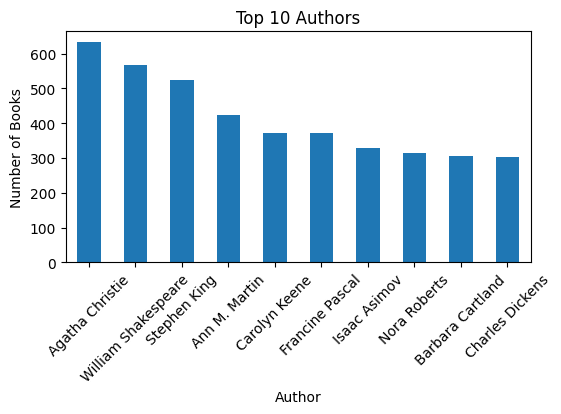

In [33]:
#Top Authors
import matplotlib.pyplot as plt
plt.figure(figsize=(6,3))
books['Book-Author'].value_counts().head(10).plot(kind='bar')
plt.title("Top 10 Authors")
plt.xlabel("Author")
plt.ylabel("Number of Books")
plt.xticks(rotation=45)
plt.show()

##### Rating Dataset

In [34]:
#Load Dataset
rating = pd.read_csv('Ratings.csv', encoding='latin-1', low_memory=False)
#Display dataset
rating.head()

,User-ID,ISBN,Book-Rating
0,276725,034545104X,0
1,276726,0155061224,5
2,276727,0446520802,0
3,276729,052165615X,3
4,276729,0521795028,6


In [35]:
rating.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1149780 entries, 0 to 1149779
Data columns (total 3 columns):
 #   Column       Non-Null Count    Dtype 
---  ------       --------------    ----- 
 0   User-ID      1149780 non-null  int64 
 1   ISBN         1149780 non-null  object
 2   Book-Rating  1149780 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 26.3+ MB


In [36]:
#Check Missing value
rating.isnull().sum()

User-ID        0
ISBN           0
Book-Rating    0
dtype: int64

In [37]:
rating.shape

(1149780, 3)

In [38]:
#Unique Values
rating['User-ID'].nunique()

105283

In [39]:
rating['ISBN'].nunique()

340556

In [40]:
rating['Book-Rating'].unique()


array([ 0,  5,  3,  6,  8,  7, 10,  9,  4,  1,  2])

In [41]:
rating['Book-Rating'].value_counts()

Book-Rating
0     716109
8     103736
10     78610
7      76457
9      67541
5      50974
6      36924
4       8904
3       5996
2       2759
1       1770
Name: count, dtype: int64

In [42]:
#Separate Ratings
explicit = rating[rating['Book-Rating'] != 0]
implicit = rating[rating['Book-Rating'] == 0]

In [43]:
#Count Explicit vs Implicit
explicit.shape

(433671, 3)

In [44]:
implicit.shape

(716109, 3)

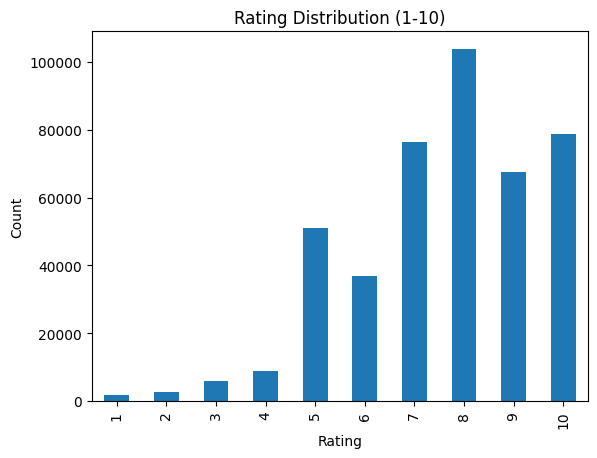

In [45]:
#Rating Distribution (Explicit)
import matplotlib.pyplot as plt

explicit['Book-Rating'].value_counts().sort_index().plot(kind='bar')
plt.title("Rating Distribution (1-10)")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

In [46]:
#Most Active Users
rating['User-ID'].value_counts().head(10)

User-ID
11676     13602
198711     7550
153662     6109
98391      5891
35859      5850
212898     4785
278418     4533
76352      3367
110973     3100
235105     3067
Name: count, dtype: int64

In [47]:
#Most Rated Books
rating['ISBN'].value_counts().head(10)

ISBN
0971880107    2502
0316666343    1295
0385504209     883
0060928336     732
0312195516     723
044023722X     647
0679781587     639
0142001740     615
067976402X     614
0671027360     586
Name: count, dtype: int64

In [48]:

rating.head()

,User-ID,ISBN,Book-Rating
0,276725,034545104X,0
1,276726,0155061224,5
2,276727,0446520802,0
3,276729,052165615X,3
4,276729,0521795028,6


In [49]:
#Check distribution first
rating['User-ID'].value_counts().describe()

count    105283.000000
mean         10.920851
std          90.562825
min           1.000000
25%           1.000000
50%           1.000000
75%           4.000000
max       13602.000000
Name: count, dtype: float64

In [50]:
rating['ISBN'].value_counts().describe()

count    340556.000000
mean          3.376185
std          12.436252
min           1.000000
25%           1.000000
50%           1.000000
75%           2.000000
max        2502.000000
Name: count, dtype: float64

In [51]:
# remove implicit first
rating = rating[rating['Book-Rating'] != 0]

# active users
active_users = rating['User-ID'].value_counts()
active_users = active_users[active_users > 5].index

rating = rating[rating['User-ID'].isin(active_users)]

# popular books
popular_books = rating['ISBN'].value_counts()
popular_books = popular_books[popular_books > 3].index

rating = rating[rating['ISBN'].isin(popular_books)]

In [52]:
rating.head()

,User-ID,ISBN,Book-Rating
122,276813,8478884831,8
133,276822,0060096195,10
134,276822,0141310340,9
137,276822,0375821813,9
141,276822,0552546933,9


In [53]:
rating.shape

(151081, 3)

In [54]:
rating['User-ID'].nunique()


11386

In [55]:
rating['ISBN'].nunique()

15048

In [56]:
#Rating Distribution
rating['Book-Rating'].value_counts().sort_index()

Book-Rating
1       473
2       809
3      1739
4      2565
5     14658
6     11565
7     25324
8     37184
9     26624
10    30140
Name: count, dtype: int64

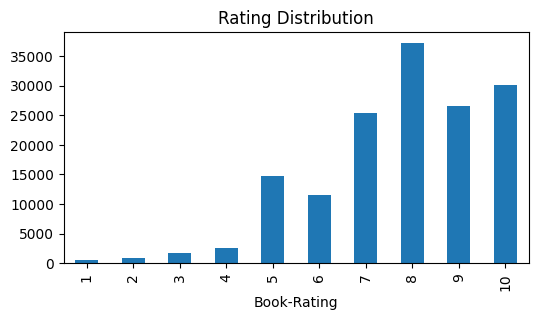

In [57]:
import matplotlib.pyplot as plt
plt.figure(figsize=(6,3))
rating['Book-Rating'].value_counts().sort_index().plot(kind='bar')
plt.title("Rating Distribution")
plt.show()

In [58]:
#Most Active Users
rating['User-ID'].value_counts().head(10)

User-ID
11676     3279
98391     1052
153662     565
16795      487
114368     418
95359      406
235105     333
104636     317
35859      315
123883     307
Name: count, dtype: int64

In [59]:
#Most Rated Books
rating['ISBN'].value_counts().head(10)

ISBN
0316666343    403
0385504209    321
0971880107    247
0312195516    229
059035342X    212
0142001740    205
0060928336    201
0679781587    199
0446672211    191
0345337662    186
Name: count, dtype: int64

In [60]:
#Book Statistics 
book_stats = rating.groupby('ISBN').agg({
    'Book-Rating': ['mean', 'count']
})

book_stats.columns = ['avg_rating', 'rating_count']
book_stats.head()

,avg_rating,rating_count
ISBN,,
0002005018,7.428571,7
0002251760,9.000000,6
0002259001,8.750000,4
0002259834,7.000000,4
0002550563,6.500000,4


In [61]:
#Top Rated Books (Reliable)
top_books = book_stats[book_stats['rating_count'] >= 10]
top_books.sort_values(by='avg_rating', ascending=False).head(10)

,avg_rating,rating_count
ISBN,,
1888054557,10.000000,11
0836213319,9.923077,13
0312099045,9.900000,10
0439425220,9.869565,23
0394800389,9.846154,13
0618002235,9.789474,19
0060256656,9.705882,17
1566404398,9.636364,11
0618002243,9.600000,15


#### Merge Datasets

In [62]:
#Merge Ratings + Books
final_df = rating.merge(book, on='ISBN')

In [63]:
#Merge with Users
final_df = final_df.merge(users, on='User-ID')

In [64]:
final_df.head()

,User-ID,ISBN,Book-Rating,Book-Title,Book-Author,Age,City,State,Country,Age_Group
0,276822,0060096195,10,The Boy Next Door,Meggin Cabot,11.0,calgary,alberta,canada,10-20
1,276822,0141310340,9,Skin and Other Stories (Now in Speak!),Roald Dahl,11.0,calgary,alberta,canada,10-20
2,276822,0375821813,9,Hoot (Newbery Honor Book),CARL HIAASEN,11.0,calgary,alberta,canada,10-20
3,276822,0689804458,8,A String in the Harp,Nancy Bond,11.0,calgary,alberta,canada,10-20
4,276822,0786817070,10,"Artemis Fowl (Artemis Fowl, Book 1)",Eoin Colfer,11.0,calgary,alberta,canada,10-20


In [65]:
final_df.shape

(145570, 10)

In [66]:
final_df.isnull().sum()

User-ID        0
ISBN           0
Book-Rating    0
Book-Title     0
Book-Author    0
Age            0
City           0
State          0
Country        0
Age_Group      0
dtype: int64

In [67]:
final_df['Book-Rating'].unique()

array([10,  9,  8,  7,  6,  5,  2,  4,  3,  1])

In [68]:
final_df.head()

,User-ID,ISBN,Book-Rating,Book-Title,Book-Author,Age,City,State,Country,Age_Group
0,276822,0060096195,10,The Boy Next Door,Meggin Cabot,11.0,calgary,alberta,canada,10-20
1,276822,0141310340,9,Skin and Other Stories (Now in Speak!),Roald Dahl,11.0,calgary,alberta,canada,10-20
2,276822,0375821813,9,Hoot (Newbery Honor Book),CARL HIAASEN,11.0,calgary,alberta,canada,10-20
3,276822,0689804458,8,A String in the Harp,Nancy Bond,11.0,calgary,alberta,canada,10-20
4,276822,0786817070,10,"Artemis Fowl (Artemis Fowl, Book 1)",Eoin Colfer,11.0,calgary,alberta,canada,10-20


##### Pivot Table

In [69]:
book_pivot = final_df.pivot_table(
    index='User-ID',
    columns='Book-Title',
    values='Book-Rating'
).fillna(0)

In [70]:
book_pivot.head()

Book-Title,"Earth Prayers From around the World: 365 Prayers, Poems, and Invocations for Honoring the Earth",Murder of a Sleeping Beauty (Scumble River Mysteries (Paperback)),"Q-Space (Star Trek The Next Generation, Book 47)",!Yo!,'Salem's Lot,...AND THE HORSE HE RODE IN ON : THE PEOPLE V. KENNETH STARR,".Hack: //Legend of the Twilight, Vol. 1",".Hack: //Legend of the Twilight, Vol. 2",01-01-00: The Novel of the Millennium,"1,000 Places to See Before You Die",...,"\Surely You're Joking, Mr. Feynman!\"": Adventures of a Curious Character""","\The Happy Prince\"" and Other Stories (Penguin Popular Classics)""","\What Do You Care What Other People Think?\"": Further Adventures of a Curious Character""",e,iI Paradiso Degli Orchi,murder@maggody.com : An Arly Hanks Mystery (Arly Hanks Mysteries (Paperback)),one hundred years of solitude,stardust,together by christmas,why I'm like this : True Stories
User-ID,,,,,,,,,,,,,,,,,,,,,
8,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
99,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
114,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
242,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
243,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [71]:
df = final_df[['User-ID', 'Book-Title', 'Book-Author', 'Country', 'Book-Rating']]

In [72]:
user_item = df.pivot_table(index='User-ID',columns='Book-Title',values='Book-Rating').fillna(0)
user_item

Book-Title,"Earth Prayers From around the World: 365 Prayers, Poems, and Invocations for Honoring the Earth",Murder of a Sleeping Beauty (Scumble River Mysteries (Paperback)),"Q-Space (Star Trek The Next Generation, Book 47)",!Yo!,'Salem's Lot,...AND THE HORSE HE RODE IN ON : THE PEOPLE V. KENNETH STARR,".Hack: //Legend of the Twilight, Vol. 1",".Hack: //Legend of the Twilight, Vol. 2",01-01-00: The Novel of the Millennium,"1,000 Places to See Before You Die",...,"\Surely You're Joking, Mr. Feynman!\"": Adventures of a Curious Character""","\The Happy Prince\"" and Other Stories (Penguin Popular Classics)""","\What Do You Care What Other People Think?\"": Further Adventures of a Curious Character""",e,iI Paradiso Degli Orchi,murder@maggody.com : An Arly Hanks Mystery (Arly Hanks Mysteries (Paperback)),one hundred years of solitude,stardust,together by christmas,why I'm like this : True Stories
User-ID,,,,,,,,,,,,,,,,,,,,,
8,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
99,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
114,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
242,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
243,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
278668,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
278694,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
278843,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### Create User Similarity Matrix

In [73]:
# Compute User Similarity
from sklearn.metrics.pairwise import cosine_similarity

#Create user_similarity 
user_similarity = cosine_similarity(user_item)

#diagonal must be 0
np.fill_diagonal(user_similarity, 0)

#user_similarity DataFrame
user_sim_df = pd.DataFrame(user_similarity,index=user_item.index,columns=user_item.index)
user_sim_df

User-ID,8,99,114,242,243,244,254,300,383,388,...,278552,278554,278582,278633,278637,278668,278694,278843,278851,278854
User-ID,,,,,,,,,,,,,,,,,,,,,
8,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,...,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
99,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,...,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
114,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,...,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
242,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,...,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
243,0.0,0.0,0.0,0.0,0.0,0.118101,0.000000,0.0,0.0,0.0,...,0.0,0.000000,0.0,0.037915,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
278668,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,...,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
278694,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,...,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
278843,0.0,0.0,0.0,0.0,0.0,0.000000,0.059488,0.0,0.0,0.0,...,0.0,0.086195,0.0,0.066085,0.0,0.0,0.0,0.0,0.0,0.0


In [74]:
#Get Similar Users
def similar_users(user_id, top_n=5):
    return user_sim_df[user_id].sort_values(ascending=False).iloc[1:top_n+1]

### Create ITEM–ITEM SIMILARITY

In [75]:
#Transpose user_item
item_item = user_item.T

# create item_similarity
item_similarity = cosine_similarity(item_item)

#Diagonal must be 0
np.fill_diagonal(item_similarity, 0)
#item similarity 
item_sim_df = pd.DataFrame(item_similarity,index=item_item.index,columns=item_item.index)
item_sim_df

Book-Title,"Earth Prayers From around the World: 365 Prayers, Poems, and Invocations for Honoring the Earth",Murder of a Sleeping Beauty (Scumble River Mysteries (Paperback)),"Q-Space (Star Trek The Next Generation, Book 47)",!Yo!,'Salem's Lot,...AND THE HORSE HE RODE IN ON : THE PEOPLE V. KENNETH STARR,".Hack: //Legend of the Twilight, Vol. 1",".Hack: //Legend of the Twilight, Vol. 2",01-01-00: The Novel of the Millennium,"1,000 Places to See Before You Die",...,"\Surely You're Joking, Mr. Feynman!\"": Adventures of a Curious Character""","\The Happy Prince\"" and Other Stories (Penguin Popular Classics)""","\What Do You Care What Other People Think?\"": Further Adventures of a Curious Character""",e,iI Paradiso Degli Orchi,murder@maggody.com : An Arly Hanks Mystery (Arly Hanks Mysteries (Paperback)),one hundred years of solitude,stardust,together by christmas,why I'm like this : True Stories
Book-Title,,,,,,,,,,,,,,,,,,,,,
"Earth Prayers From around the World: 365 Prayers, Poems, and Invocations for Honoring the Earth",0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0
Murder of a Sleeping Beauty (Scumble River Mysteries (Paperback)),0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.314144,0.0
"Q-Space (Star Trek The Next Generation, Book 47)",0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0
!Yo!,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0
'Salem's Lot,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
murder@maggody.com : An Arly Hanks Mystery (Arly Hanks Mysteries (Paperback)),0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0
one hundred years of solitude,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.134752,0.000000,0.0
stardust,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.071278,0.0,...,0.076902,0.0,0.0,0.0,0.0,0.0,0.134752,0.000000,0.000000,0.0


In [76]:
#Get Similar Books
def similar_books(book_name, top_n=5):
    return item_sim_df[book_name].sort_values(ascending=False).iloc[1:top_n+1]

### COUNTRY-BASED POPULAR BOOKS

In [77]:

country_popular = (df.groupby(['Country', 'Book-Title'])['Book-Rating'].count().reset_index(name='count'))

country_popular = country_popular.sort_values(['Country', 'count'], ascending=[True, False])

In [78]:
#Get Country Recommendations
def country_recommend(user_id, top_n=5):
    user_country = df[df['User-ID'] == user_id]['Country'].iloc[0]
    
    return country_popular[country_popular['Country'] == user_country]['Book-Title'].head(top_n).tolist()

### AUTHOR-BASED POPULAR BOOKS

In [79]:
author_popular = (df.groupby(['Book-Author', 'Book-Title'])['Book-Rating'].count().reset_index(name='count'))

author_popular = author_popular.sort_values(['Book-Author', 'count'], ascending=[True, False])

In [80]:
#Get Author Recommendations
def author_recommend(user_id, top_n=5):
    user_authors = df[df['User-ID'] == user_id]['Book-Author'].unique()
    
    return author_popular[author_popular['Book-Author'].isin(user_authors)]['Book-Title'].head(top_n).tolist()

In [81]:
def recommend_books(user_id, top_n=10):

    if user_id not in user_item.index:
        return ["User not found"]

    # User–User
    sim_users = similar_users(user_id, top_n=5).index
    
    user_books = set()
    for u in sim_users:
        books = user_item.loc[u]
        user_books.update(books[books > 0].index)

    # Item–Item
    user_rated = user_item.loc[user_id]
    user_rated = user_rated[user_rated > 0].index

    item_books = set()
    for book in user_rated:
        if book in item_sim_df.columns:
            item_books.update(similar_books(book, top_n=3).index)

    
    #  Country-based
    country_books = set(country_recommend(user_id, top_n=5))

    #  Author-based
    author_books = set(author_recommend(user_id, top_n=5))

    
    # Combine
    from collections import Counter

    all_books = []

    # add weights
    all_books += list(user_books) * 4
    all_books += list(item_books) * 5
    all_books += list(country_books) * 1
    all_books += list(author_books) * 2

    # count frequency (ranking)
    book_scores = Counter(all_books)

    # remove already read
    for book in user_rated:
        book_scores.pop(book, None)

    # top results
    recommended = [book for book, _ in book_scores.most_common(top_n)]

    return recommended

In [82]:
recommend_books(276822)

['If the Slipper Fits (Avon Romance)',
 'Just Desserts',
 'Pure Dead Magic',
 'Snow Place to Die : A Bed-and-Breakfast Mystery (Bed-And-Breakfast Mysteries (Paperback))',
 'A Star Called Henry (Doyle, Roddy, Last Roundup, V. 1.)',
 'A Story for Europe (Bloomsbury Classics)',
 'Artemis Fowl: The Arctic Incident - Book #2 (Artemis Fowl (Mass Market))',
 "A Conspiracy of Paper : A Novel (Ballantine Reader's Circle)",
 'Scruples',
 'Echo']

In [83]:
final_df.to_csv("final_df.csv", index=False)

In [84]:
books[['Book-Title','Image-URL-M']].drop_duplicates().to_csv(
    'books_with_urls.csv',
    index=False
)

In [85]:
print(user_item.shape)
print(user_sim_df.shape)
print(item_sim_df.shape)
print(final_df.shape)

(11153, 12859)
(11153, 11153)
(12859, 12859)
(145570, 10)


In [86]:
recommend_books(276822)

['If the Slipper Fits (Avon Romance)',
 'Just Desserts',
 'Pure Dead Magic',
 'Snow Place to Die : A Bed-and-Breakfast Mystery (Bed-And-Breakfast Mysteries (Paperback))',
 'A Star Called Henry (Doyle, Roddy, Last Roundup, V. 1.)',
 'A Story for Europe (Bloomsbury Classics)',
 'Artemis Fowl: The Arctic Incident - Book #2 (Artemis Fowl (Mass Market))',
 "A Conspiracy of Paper : A Novel (Ballantine Reader's Circle)",
 'Scruples',
 'Echo']

In [87]:
import pickle
import os

folder = r"C:\Users\rglra\Desktop\excelr\Intern\First_Project"

os.makedirs(folder, exist_ok=True)

with open(os.path.join(folder, "user_item.pkl"), "wb") as f:
    pickle.dump(user_item, f)

with open(os.path.join(folder, "user_sim_df.pkl"), "wb") as f:
    pickle.dump(user_sim_df, f)

with open(os.path.join(folder, "item_sim_df.pkl"), "wb") as f:
    pickle.dump(item_sim_df, f)

final_df.to_pickle(
    os.path.join(folder, "final_df.pkl")
)

print("Deployment files saved successfully")

Deployment files saved successfully
